In [1]:
import sys
from pathlib import Path
import numpy as np
from sklearn.metrics import roc_auc_score

# Adiciona a raiz do projeto ao PATH, caso necessário
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import pandas as pd
import joblib

from src.modeling.modeling import (
    avaliar_modelo,
    comparar_modelos
)

from src.evaluation.evaluation import (
    criar_shap_explainer,
    verificar_eficiencia_shap,
    plot_shap_waterfall,
    plot_shap_summary,
    plot_shap_dependence
)

from src.visualization.visualization import (
    plot_distribuicao_target,
    plot_mapa_correlacao,
    plot_comparacao_modelos,
    plot_top_features,
    plot_curva_roc,
    plot_matriz_confusao,
    plot_distribuicao_probabilidades
)

C:\Users\monef\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
objetos_modelagem = joblib.load(
    "../data/objetos_modelagem.pkl"
)

print(objetos_modelagem.keys())

X_train_processado = objetos_modelagem["X_train"]
X_test_processado = objetos_modelagem["X_test"]

y_train = objetos_modelagem["y_train"]
y_test = objetos_modelagem["y_test"]

preprocessor = objetos_modelagem["preprocessor"]

features_selecionadas = objetos_modelagem["features_selecionadas"]

modelo_dt = joblib.load("../data/modelo_decision_tree.pkl")
modelo_rf = joblib.load("../data/modelo_random_forest.pkl")
modelo_xgb = joblib.load("../data/modelo_xgboost.pkl")

dict_keys(['X_train', 'X_test', 'y_train', 'y_test', 'preprocessor', 'features_selecionadas'])


In [3]:
# Criar explainer e calcular SHAP values
explainer, shap_values, expected_value, X_amostra = criar_shap_explainer(
    modelo_rf,
    X_train_processado,
    amostra=5000
)

Shape dos SHAP values: (5000, 14)
Valor base (expected value): 0.4999


In [4]:
importancia_media = np.abs(shap_values).mean(axis=0)

resumo = pd.DataFrame({
    "feature": X_amostra.columns,
    "importancia_shap": importancia_media
}).sort_values("importancia_shap", ascending=False)

resumo

,feature,importancia_shap
0,numericas_minmax__taxa_alfabetizacao_2023,0.039844
1,numericas_minmax__meta_alfabetizacao_2024,0.033929
2,numericas_minmax__percentual_participacao_2024,0.033802
5,numericas_robust__indice_analfabetismo_2022,0.014569
4,numericas_minmax__inse_2023,0.011254
13,passthrough__meta_atingida,0.009759
11,categoricas__nome_regiao_Sul,0.009270
3,numericas_minmax__rendimento_domiciliar_2022,0.009117
10,categoricas__nome_regiao_Sudeste,0.008328
7,categoricas__nome_regiao_Centro-Oeste,0.004473


In [5]:
# Verificação de sanidade 
verificar_eficiencia_shap(modelo_rf, shap_values, expected_value, X_amostra)

Instância 0:
  Previsão do modelo:  0.531971
  Valor base + Σ SHAP: 0.531971
  Diferença:           0.0000000000

Instância 1:
  Previsão do modelo:  0.612156
  Valor base + Σ SHAP: 0.612156
  Diferença:           0.0000000000

Instância 2:
  Previsão do modelo:  0.478122
  Valor base + Σ SHAP: 0.478122
  Diferença:           0.0000000000

Instância 3:
  Previsão do modelo:  0.420671
  Valor base + Σ SHAP: 0.420671
  Diferença:           0.0000000000

Instância 4:
  Previsão do modelo:  0.378801
  Valor base + Σ SHAP: 0.378801
  Diferença:           0.0000000000



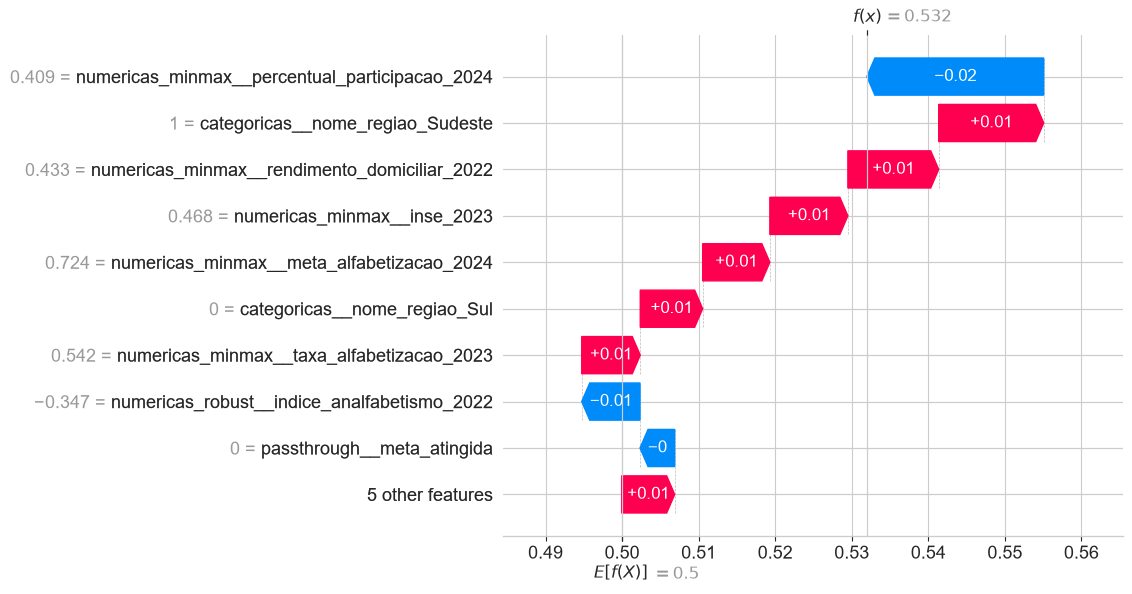

In [6]:
# Waterfall
plot_shap_waterfall(shap_values, expected_value, X_amostra, indice=0)

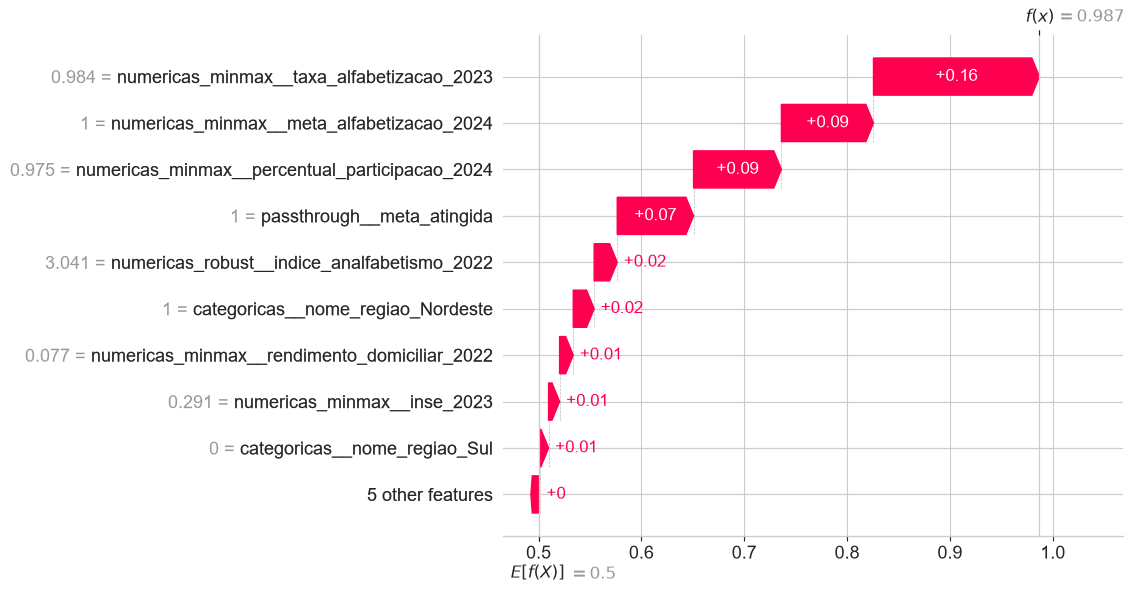

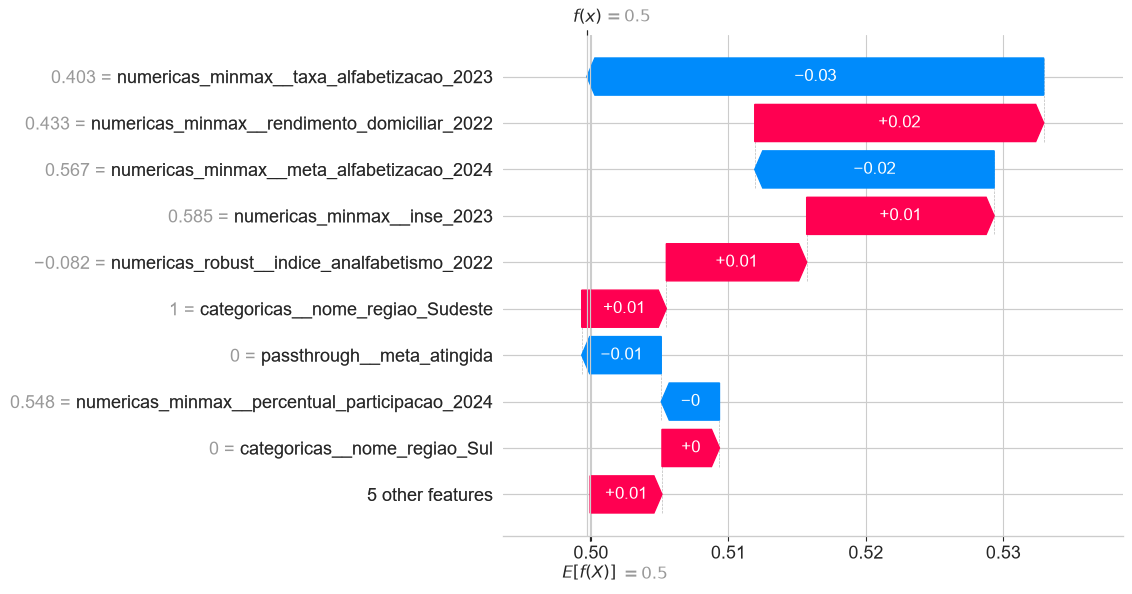

In [7]:
# analisando apenas casos com mais probabilidade e incerteza

probabilidades = modelo_rf.predict_proba(X_amostra)[:, 1]

indice_alta_confianca = probabilidades.argmax()  # instância que o modelo tem mais certeza 
indice_baixa_confianca = np.abs(probabilidades - 0.5).argmin()  # instância mais incerta

plot_shap_waterfall(shap_values, expected_value, X_amostra, indice=indice_alta_confianca)
plot_shap_waterfall(shap_values, expected_value, X_amostra, indice=indice_baixa_confianca)

O modelo demonstra alta assertividade quando os indicadores de desempenho recente
(`taxa_alfabetizacao_2023`, `meta_alfabetizacao_2024`, `percentual_participacao_2024`,
`meta_atingida`) apresentam valores extremos, mas perde capacidade discriminativa em
casos intermediários — que, dado o perfil da base, representam parcela relevante dos
registros. Esse padrão está diretamente alinhado ao diagnóstico obtido na etapa de
seleção de features: a informação preditiva mais forte vem de indicadores de
desempenho já observados, enquanto variáveis de contexto socioeconômico
(`inse_2023`, `rendimento_domiciliar_2022`) contribuem de forma marginal e
consistente em ambos os cenários, sem alterar significativamente a decisão do modelo.

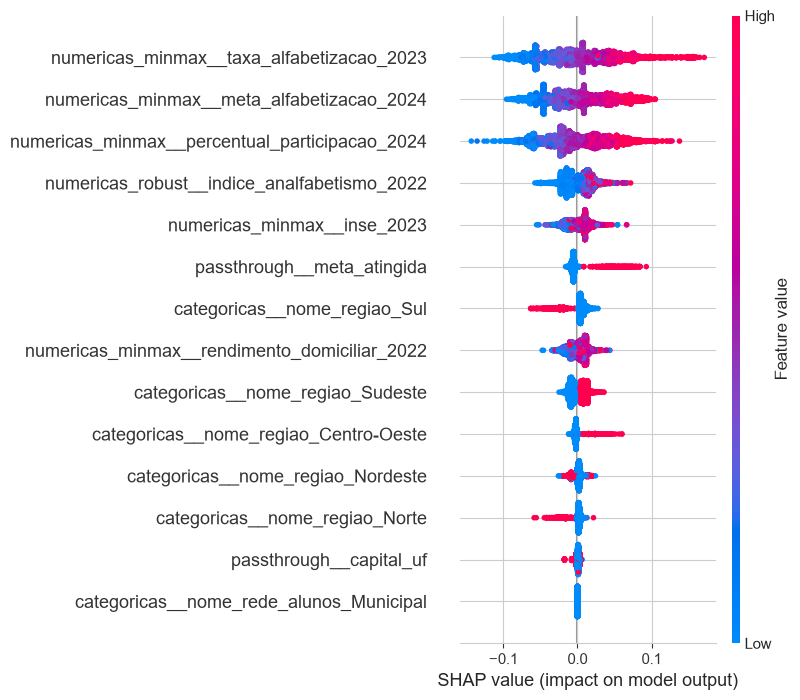

In [8]:
# Summary Plot - visão global 
plot_shap_summary(shap_values, X_amostra)

**Indicadores de desempenho recente dominam a decisão do modelo**: `taxa_alfabetizacao_2023`,
  `meta_alfabetizacao_2024` e `percentual_participacao_2024` apresentam relação forte e
  direcional — valores altos empurram a previsão para "alfabetizado", valores baixos
  empurram para "não alfabetizado". Isso é coerente com a intuição do domínio: bom
  desempenho histórico é o melhor preditor de bom desempenho atual.

**`indice_analfabetismo_2022`** confirma a direção esperada no agregado (índice alto
  reduz a probabilidade de alfabetização), validando a robustez do modelo mesmo diante
  de exceções pontuais observadas em instâncias individuais.

**`meta_atingida`** se destaca como a variável de efeito mais bem definido e "limpo"
  do modelo — separação nítida entre os grupos que bateram e não bateram a meta.

**Variáveis de região** (`nome_regiao_*`) mostram efeito direcional coerente com o
  resultado do teste qui-quadrado da etapa de pré-processamento, confirmando de forma
  independente (via SHAP) o que já havia sido identificado estatisticamente. Boa
  consistência metodológica entre as etapas do projeto.

<Figure size 800x600 with 0 Axes>

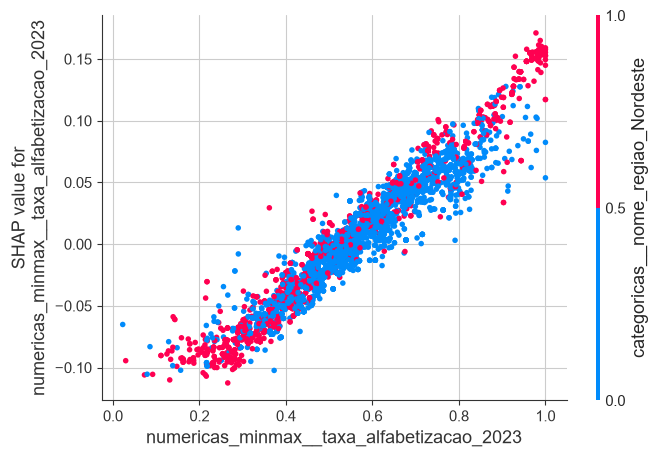

In [9]:
# Dependence Plot 
plot_shap_dependence("numericas_minmax__taxa_alfabetizacao_2023", shap_values, X_amostra)

<Figure size 800x600 with 0 Axes>

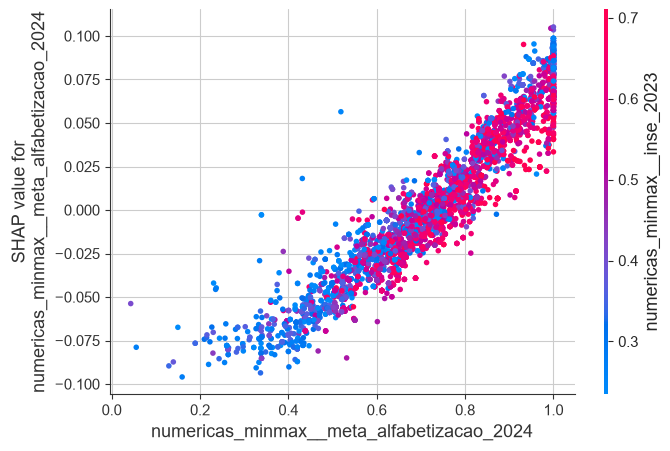

In [10]:
plot_shap_dependence("numericas_minmax__meta_alfabetizacao_2024", shap_values, X_amostra)

**Dependence Plots — Interações entre Variáveis**

Os Dependence Plots das duas features mais importantes revelam relações claras,
crescentes e quase lineares entre seus valores e o impacto na previsão (SHAP value),
confirmando visualmente por que são as variáveis de maior peso no modelo.

- **`taxa_alfabetizacao_2023`**: relação fortemente linear e monotônica com o SHAP
  value. A coloração por `nome_regiao_Nordeste` sugere uma leve interação: para uma
  mesma taxa, municípios do Nordeste apresentam impacto ligeiramente menor do que
  municípios de outras regiões, na faixa intermediária de valores.

- **`meta_alfabetizacao_2024`**: relação também crescente e consistente. A interação
  com `inse_2023` indica que, para metas de alfabetização elevadas, municípios com
  melhor índice socioeconômico convertem essa meta em um impacto positivo maior,
  sugerindo que o contexto socioeconômico modula a eficácia de metas ambiciosas.

Essas interações não seriam identificáveis pelos testes estatísticos
utilizados na etapa de seleção de features (Pearson, Spearman), evidenciando a
capacidade do modelo de capturar relações não-lineares e efeitos combinados entre
variáveis, um ganho de interpretabilidade proporcionado especificamente pela
análise SHAP.

In [11]:
resultado_dt_treino = avaliar_modelo(modelo_dt, X_train_processado, y_train, "Decision Tree - Treino")
resultado_dt_teste  = avaliar_modelo(modelo_dt, X_test_processado, y_test, "Decision Tree - Teste")

resultado_rf_treino = avaliar_modelo(modelo_rf, X_train_processado, y_train, "Random Forest - Treino")
resultado_rf_teste  = avaliar_modelo(modelo_rf, X_test_processado, y_test, "Random Forest - Teste")

resultado_xgb_treino = avaliar_modelo(modelo_xgb, X_train_processado, y_train, "XGBoost - Treino")
resultado_xgb_teste  = avaliar_modelo(modelo_xgb, X_test_processado, y_test, "XGBoost - Teste")

comparacao_final = comparar_modelos([
    resultado_dt_treino, resultado_dt_teste,
    resultado_rf_treino, resultado_rf_teste,
    resultado_xgb_treino, resultado_xgb_teste
])

comparacao_final



===== Decision Tree - Treino =====
Accuracy:  0.6048
Precision: 0.6037
Recall:    0.7292
F1-Score:  0.6605
ROC-AUC:   0.6375

Matriz de confusão:
[[312937 358383]
 [202731 545857]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.47      0.53    671320
           1       0.60      0.73      0.66    748588

    accuracy                           0.60   1419908
   macro avg       0.61      0.60      0.59   1419908
weighted avg       0.61      0.60      0.60   1419908


===== Decision Tree - Teste =====
Accuracy:  0.6043
Precision: 0.6034
Recall:    0.7277
F1-Score:  0.6598
ROC-AUC:   0.6365

Matriz de confusão:
[[ 78325  89505]
 [ 50958 136190]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.47      0.53    167830
           1       0.60      0.73      0.66    187148

    accuracy                           0.60    354978
   macro avg       0.60      0.60      0.59 

,modelo,accuracy,precision,recall,f1,roc_auc
0,Decision Tree - Treino,0.604824,0.603664,0.729182,0.660513,0.637538
1,Decision Tree - Teste,0.604305,0.603425,0.727713,0.659767,0.636462
2,Random Forest - Treino,0.625578,0.656388,0.608177,0.631363,0.678243
4,XGBoost - Treino,0.623747,0.654982,0.605044,0.629023,0.675256
3,Random Forest - Teste,0.621901,0.652949,0.603709,0.627364,0.672655
5,XGBoost - Teste,0.620393,0.651718,0.601321,0.625506,0.670769


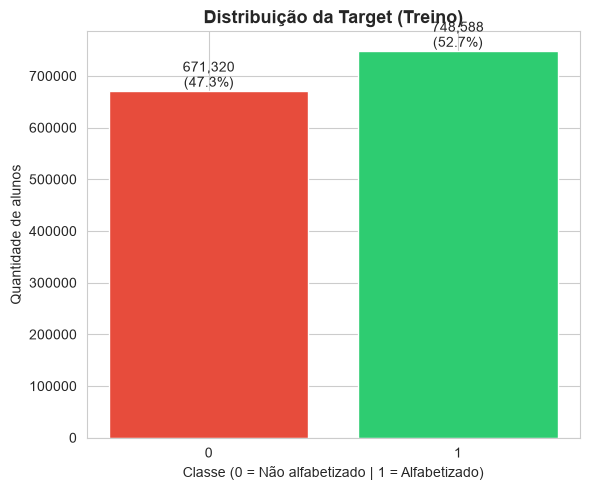

In [12]:

# Distribuição da target
plot_distribuicao_target(y_train)


As variaveis estao relativamente balanceadas.

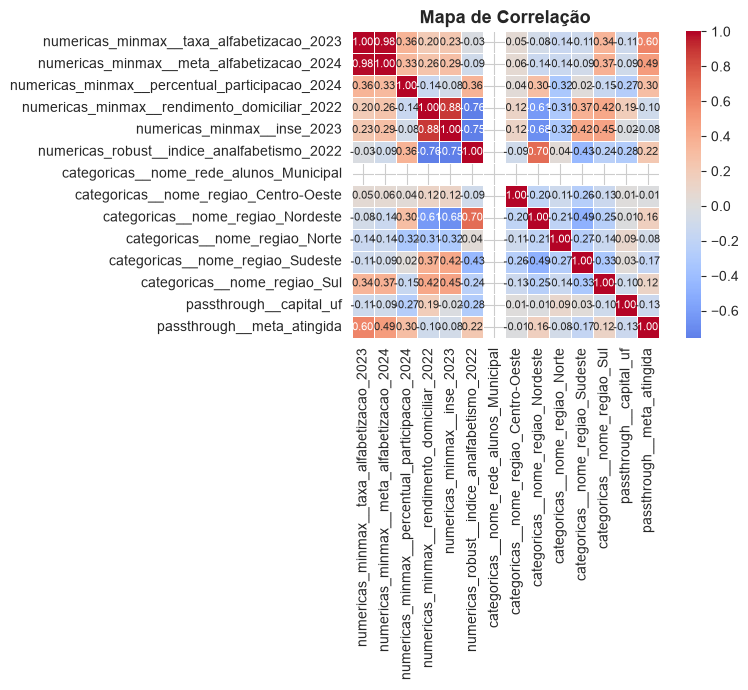

In [13]:


# Mapa de correlação (EDA - variáveis numéricas)
plot_mapa_correlacao(X_train_processado)


 **Relações que fazem sentido substantivo**

- **INSE (2023) e rendimento domiciliar (2022)** apresentam correlação positiva forte
  (0,88), esperado, já que o Índice Socioeconômico é fortemente influenciado pela
  renda das famílias.

- **Região Nordeste e índice de analfabetismo (2022)** apresentam correlação positiva
  (0,70), reflete uma desigualdade regional histórica e conhecida no país.

- **Índice de analfabetismo** apresenta correlação negativa com **rendimento
  domiciliar** (-0,76) e **INSE** (-0,75), quanto maior o poder aquisitivo/contexto
  socioeconômico, menor o índice de analfabetismo, uma relação bem documentada na
  literatura educacional.

- **Região Sudeste** apresenta correlação negativa com **índice de analfabetismo**
  (-0,43) e com **região Nordeste** (-0,49 ver nota metodológica), consistente com
  o Sudeste sendo historicamente a região de menor analfabetismo do país.

- **Região Sul** segue o mesmo padrão da Sudeste, com correlação negativa com o
  índice de analfabetismo (-0,24) e positiva com rendimento domiciliar (0,42), mais
  moderada, mas na mesma direção, reforçando a leitura de desigualdade regional.

- **`taxa_alfabetizacao_2023` e `meta_alfabetizacao_2024`** apresentam correlação
  muito forte (0,98), indicando que a meta é calculada diretamente a partir do
  desempenho observado no ano anterior, confirma numericamente a relação de
  dependência já identificada na análise SHAP entre essas variáveis e `meta_atingida`.

- **`percentual_participacao_2024`** mostra correlações moderadas (0,30–0,40) com as
  demais variáveis numéricas, indicando que carrega informação relativamente
  independente das demais, coerente com sua relevância nas análises de importância
  do modelo.

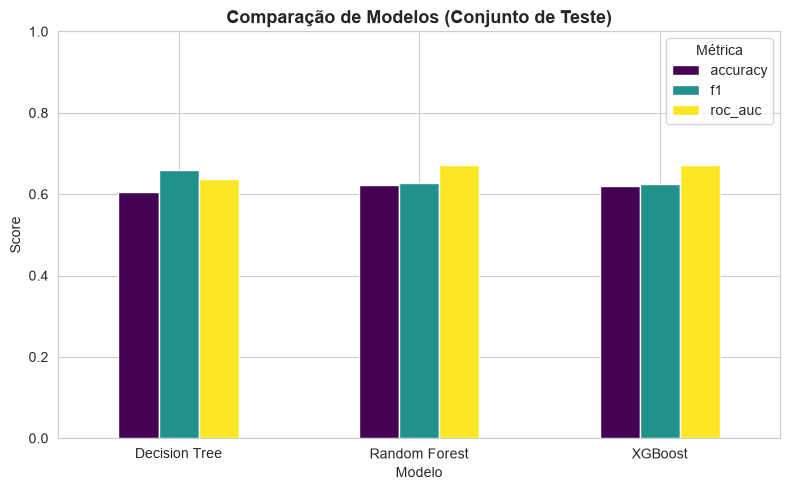

In [14]:
# Comparação entre os 3 modelos testados
plot_comparacao_modelos(comparacao_final)

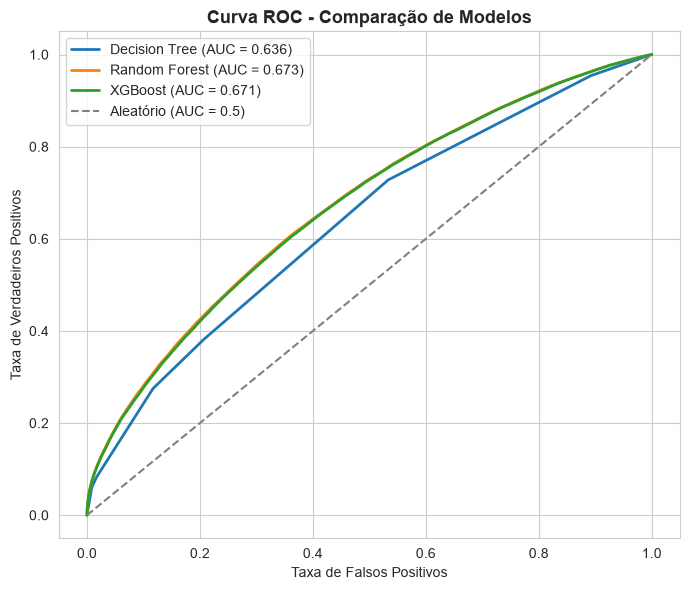

In [15]:
# Curva ROC comparando os modelos
plot_curva_roc(
    {"Decision Tree": modelo_dt, "Random Forest": modelo_rf, "XGBoost": modelo_xgb},
    X_test_processado,
    y_test
)

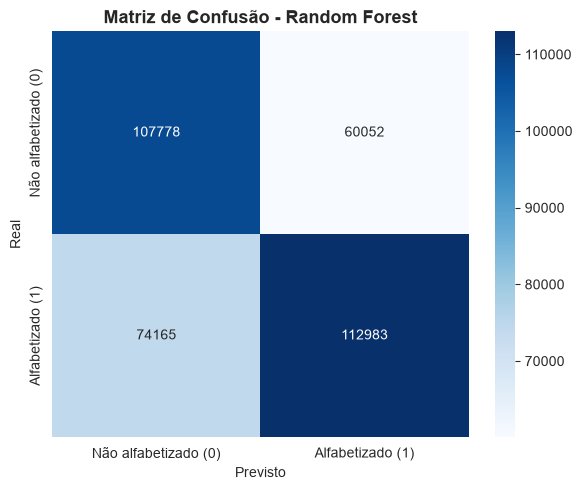

In [16]:
# Matriz de confusão do modelo final (Random Forest)
plot_matriz_confusao(modelo_rf, X_test_processado, y_test, nome_modelo="Random Forest")


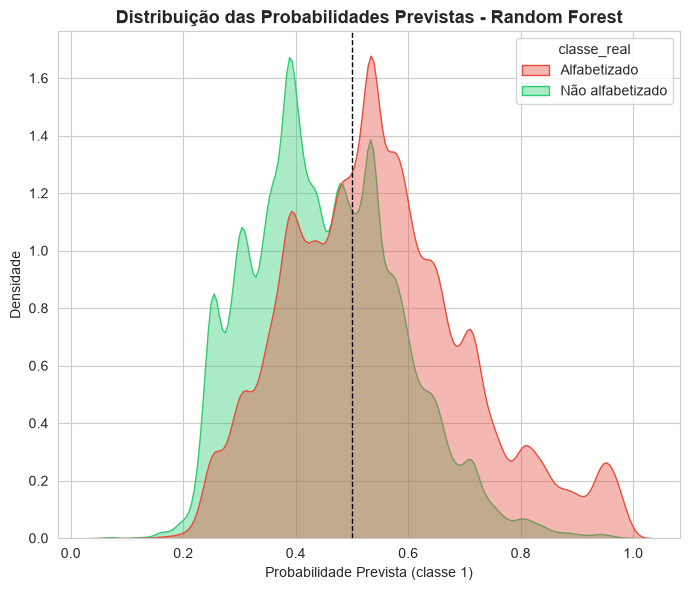

In [17]:
# Distribuição das probabilidades previstas (modelo final)
plot_distribuicao_probabilidades(modelo_rf, X_test_processado, y_test, nome_modelo="Random Forest")


Nota-se ainda uma cauda mais longa e um pico secundário na classe "alfabetizado"
próximo a 1,0, sugerindo a existência de um subgrupo de casos com indicadores de
desempenho muito favoráveis, para os quais o modelo consegue prever com alta
confiança, corroborando os achados da análise SHAP local (waterfall plots) sobre
casos de alta e baixa confiança.